# AI-Generated vs Real Image Detector (Fast T4 Edition)
EfficientNet-B0 on a balanced 10k-image subset, optimized for Kaggle T4 GPUs.

**Resume-quality project**, not a research benchmark — trains in minutes, not hours.

In [14]:
# 1. Install & imports (run this cell first, every time)
!pip install grad-cam -q

import os, time, random, warnings, collections
from pathlib import Path
from copy import deepcopy

warnings.filterwarnings('ignore', message='Palette images with Transparency')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True   # avoid crashes on corrupted images
Image.MAX_IMAGE_PIXELS = None            # avoid DecompressionBomb warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [15]:
# 2. Find the dataset folder
print(os.listdir('/kaggle/input/datasets'))

['tristanzhang32']


In [16]:
# 3. Set DATA_ROOT — points at the folder containing class subfolders (fake/ real/)
# The dataset is structured as:
#   ai-generated-images-vs-real-images/
#     train/
#       fake/  real/
#     test/
#       fake/  real/
# We always train on train/ and keep test/ completely separate.

BASE = Path('/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images')

# Try common base paths in case the dataset is mounted differently
for candidate_base in [
    Path('/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images'),
    Path('/kaggle/input/ai-generated-images-vs-real-images'),
]:
    if candidate_base.exists():
        BASE = candidate_base
        break

print('BASE =', BASE)
print('Contents of BASE:', [p.name for p in BASE.iterdir()])

# Always use the train/ subfolder for training
DATA_ROOT = BASE / 'train'

# Verify it contains class folders (not more split folders)
if DATA_ROOT.exists():
    class_candidates = [d.name for d in DATA_ROOT.iterdir() if d.is_dir()]
    print('DATA_ROOT =', DATA_ROOT)
    print('Classes   =', class_candidates)
else:
    # Fallback: walk to find a folder with non-split subfolders
    SPLIT_NAMES = {'train', 'test', 'val', 'validation'}
    DATA_ROOT = None
    for p in sorted(BASE.rglob('*')):
        if p.is_dir():
            subdirs = [d for d in p.iterdir() if d.is_dir()]
            names = {d.name.lower() for d in subdirs}
            if len(subdirs) >= 2 and not names.issubset(SPLIT_NAMES):
                DATA_ROOT = p
                break
    print('DATA_ROOT =', DATA_ROOT)
    print('Classes   =', [d.name for d in DATA_ROOT.iterdir() if d.is_dir()])


BASE = /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images
Contents of BASE: ['test', 'train']
DATA_ROOT = /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train
Classes   = ['fake', 'real']


## Configuration
All the speed-related knobs are collected here. The dataset is ~52GB, so we
**never run `ImageFolder` over the full thing for training** — instead we
build a small, class-balanced subset first (Section 4), and only that subset
gets wrapped in a Dataset/DataLoader.

### Image size: why 224
EfficientNet-B0's pretrained ImageNet weights were trained at 224x224. Using
the matching size means the pretrained convolutional filters are already
well-calibrated for this resolution. Dropping to 128 or 160 saves a little
compute but tends to cost a noticeable amount of accuracy for B0 specifically,
since its architecture (compound-scaled from a small base) is already tuned
for 224. Given our dataset is now small (10k images), the per-epoch cost at
224px is already low, so there's no need to trade accuracy for speed here.

In [17]:
# 4a. Speed / training configuration
IMG_SIZE          = 224   # matches EfficientNet-B0 pretrained resolution
BATCH             = 64    # T4 (15GB) comfortably fits B0 @224 with batch 64
EPOCHS            = 10    # 10 epochs gives the frozen head enough time to converge
LR                = 1e-4
SAMPLES_PER_CLASS = 5000  # 5,000 REAL + 5,000 FAKE = 10,000 total

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),  # resize+crop in one step
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Config ready')

Config ready


## 4b. Build a balanced 10k-image subset
Instead of indexing the full 52GB dataset with `ImageFolder` (which itself can
be slow to construct and consumes a lot of memory for the full file list), we:
1. List filenames per class directly from disk (cheap)
2. Randomly sample `SAMPLES_PER_CLASS` per class
3. Build a small dataset from just those ~10k paths

This keeps class balance exact (5000/5000) and avoids ever touching the other
~100k+ images on disk.

In [18]:
# 4c. Sample SAMPLES_PER_CLASS images per class
VALID_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

class_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir()])
CLASS_NAMES = [d.name for d in class_dirs]
N_CLASSES = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)

sampled_paths = []   # list of (path, label_idx)
for label_idx, cdir in enumerate(class_dirs):
    # rglob handles nested subfolders within a class dir, if any
    all_files = [p for p in cdir.rglob('*') if p.suffix.lower() in VALID_EXTS]
    print(f'{cdir.name}: {len(all_files)} files found on disk')

    n_take = min(SAMPLES_PER_CLASS, len(all_files))
    chosen = random.sample(all_files, n_take)
    sampled_paths.extend([(p, label_idx) for p in chosen])

print(f'\nTotal sampled: {len(sampled_paths)} images '
      f'({SAMPLES_PER_CLASS} per class target)')

Classes: ['fake', 'real']
fake: 24000 files found on disk
real: 24000 files found on disk

Total sampled: 10000 images (5000 per class target)


In [19]:
# 4d. Train / validation / test split (70 / 15 / 15) on the sampled subset
all_paths  = [str(p) for p, _ in sampled_paths]
all_labels = [lbl for _, lbl in sampled_paths]

idx_all = list(range(len(all_paths)))
train_idx, temp_idx = train_test_split(
    idx_all, test_size=0.30, stratify=all_labels, random_state=SEED)
temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=SEED)

print(f'Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}')


class ImagePathDataset(torch.utils.data.Dataset):
    """Minimal dataset: loads images from a list of (path, label) pairs."""
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')  # always convert to RGB
        return self.transform(img), self.labels[idx]


def make_subset(idx_list, transform):
    paths  = [all_paths[i]  for i in idx_list]
    labels = [all_labels[i] for i in idx_list]
    return ImagePathDataset(paths, labels, transform)

train_ds = make_subset(train_idx, train_tf)
val_ds   = make_subset(val_idx,   eval_tf)
test_ds  = make_subset(test_idx,  eval_tf)

print('Datasets ready')

Train: 7000  Val: 1500  Test: 1500
Datasets ready


In [20]:
# 4d-debug. Sanity checks: label balance + label mapping + one batch inspection
print('Class names (index -> name):')
for i, c in enumerate(CLASS_NAMES):
    print(f'  {i} -> {c}')

print('\nTrain labels   :', collections.Counter([all_labels[i] for i in train_idx]))
print('Val labels     :', collections.Counter([all_labels[i] for i in val_idx]))
print('Test labels    :', collections.Counter([all_labels[i] for i in test_idx]))

# Confirm each class's source folder is consistent (catch mislabeled folders)
print('\nSample file paths per class:')
for label_idx, cdir in enumerate(class_dirs):
    examples = [p for p, l in sampled_paths if l == label_idx][:2]
    print(f'  Label {label_idx} ({CLASS_NAMES[label_idx]}):')
    for ex in examples:
        print(f'    {ex}')

# Check for path overlap between train/val/test (data leakage)
train_paths_set = set(all_paths[i] for i in train_idx)
val_paths_set   = set(all_paths[i] for i in val_idx)
test_paths_set  = set(all_paths[i] for i in test_idx)
print('\nTrain/Val overlap :', len(train_paths_set & val_paths_set))
print('Train/Test overlap:', len(train_paths_set & test_paths_set))
print('Val/Test overlap  :', len(val_paths_set & test_paths_set))

# Load one image directly to confirm transform pipeline works
sample_img, sample_label = train_ds[0]
print('\nSample tensor shape:', sample_img.shape)
print('Sample tensor mean/std:', sample_img.mean().item(), sample_img.std().item())
print('Sample label:', sample_label, '->', CLASS_NAMES[sample_label])

Class names (index -> name):
  0 -> fake
  1 -> real

Train labels   : Counter({1: 3500, 0: 3500})
Val labels     : Counter({1: 750, 0: 750})
Test labels    : Counter({0: 750, 1: 750})

Sample file paths per class:
  Label 0 (fake):
    /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train/fake/4862.jpg
    /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train/fake/12403.jpg
  Label 1 (real):
    /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train/real/11505.jpg
    /kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train/real/21729.jpg

Train/Val overlap : 0
Train/Test overlap: 0
Val/Test overlap  : 0

Sample tensor shape: torch.Size([3, 224, 224])
Sample tensor mean/std: -0.19682246446609497 0.8630862236022949
Sample label: 1 -> real


In [21]:
# 4e. DataLoaders — tuned for Kaggle T4
train_loader = DataLoader(
    train_ds, batch_size=BATCH, shuffle=True,
    num_workers=2, pin_memory=True)

val_loader = DataLoader(
    val_ds, batch_size=BATCH, shuffle=False,
    num_workers=2, pin_memory=True)

test_loader = DataLoader(
    test_ds, batch_size=BATCH, shuffle=False,
    num_workers=2, pin_memory=True)

print('DataLoaders ready')
print(f'  train batches: {len(train_loader)}')
print(f'  val batches  : {len(val_loader)}')
print(f'  test batches : {len(test_loader)}')

DataLoaders ready
  train batches: 110
  val batches  : 24
  test batches : 24


## 5. Model builder
Only EfficientNet-B0 is trained by default. The factory function is kept
generic so other architectures can be re-enabled later just by adding an
`elif` branch and including the name in `MODEL_NAMES`.

In [22]:
# 5. Model builder (EfficientNet-B0 by default; extensible)
def build_model(name, num_classes=2, freeze_backbone=True):
    if name == 'efficientnet_b0':
        m = models.efficientnet_b0(weights='IMAGENET1K_V1')

        if freeze_backbone:
            for param in m.features.parameters():
                param.requires_grad = False

        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_f, num_classes))
        return m

    # --- To re-enable other models later, add branches like this: ---
    # elif name == 'efficientnet_b3':
    #     m = models.efficientnet_b3(weights='IMAGENET1K_V1')
    #     in_f = m.classifier[1].in_features
    #     m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_f, num_classes))
    #     return m
    # elif name == 'resnet50':
    #     m = models.resnet50(weights='IMAGENET1K_V1')
    #     in_f = m.fc.in_features
    #     m.fc = nn.Linear(in_f, num_classes)
    #     return m

    raise ValueError(f'Unknown model: {name}')


def gradcam_layer(model, name):
    if name == 'efficientnet_b0':
        return [model.features[-1][0]]
    # elif name == 'efficientnet_b3':
    #     return [model.features[-1][0]]
    # elif name == 'resnet50':
    #     return [model.layer4[-1].conv3]
    raise ValueError(f'No Grad-CAM layer defined for: {name}')

print('Model builder ready')

Model builder ready


## 6. Training function — AMP enabled
Mixed precision (`torch.autocast` + `GradScaler`) runs most ops in float16 on
the T4's Tensor Cores while keeping a float32 master copy of weights for
stability. This roughly halves memory use and often gives a 1.5-3x speedup on
T4 for CNNs like EfficientNet.

In [23]:
# 6. Training function with AMP + per-epoch timing + diagnostics
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

def run_epoch(model, loader, criterion, optimizer=None, train=True, collect_preds=False):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels_ = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
                out  = model(imgs)
                loss = criterion(out, labels)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            preds = out.argmax(1)
            total_loss += loss.item() * imgs.size(0)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

            if collect_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels_.extend(labels.cpu().numpy())

    if collect_preds:
        return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels_)
    return total_loss / total, correct / total


def train_model(name, freeze_backbone=True, epochs=None, lr=None, phase_label="", pretrained_model=None):
    _epochs = epochs if epochs is not None else EPOCHS
    _lr = lr if lr is not None else LR
    label = f'{name} [{phase_label}]' if phase_label else name
    print(f'Training {label} | epochs={_epochs} lr={_lr} freeze={freeze_backbone}')
    if pretrained_model is not None:
        model = pretrained_model
    else:
        model = build_model(name, N_CLASSES, freeze_backbone=freeze_backbone).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=_lr)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'Trainable params: {trainable:,} / {total:,}')

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'epoch_time': []}
    best_val_loss = float('inf')
    best_val_acc = 0
    best_state = None

    total_start = time.time()
    for epoch in range(1, _epochs + 1):
        epoch_start = time.time()

        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        va_loss, va_acc, va_preds, va_labels = run_epoch(
            model, val_loader, criterion, train=False, collect_preds=True)

        epoch_time = time.time() - epoch_start

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['epoch_time'].append(epoch_time)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_val_acc = va_acc
            best_state = deepcopy(model.state_dict())

        print(f'Epoch {epoch}/{_epochs}: '
              f'train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} '
              f'val_loss={va_loss:.4f} val_acc={va_acc:.3f} '
              f'time={epoch_time:.1f}s')

        # --- 6. Prediction distribution on validation set ---
        pred_counts = collections.Counter(va_preds.tolist())
        true_counts = collections.Counter(va_labels.tolist())
        print(f'  Val predicted distribution: '
              f'{ {CLASS_NAMES[k]: v for k, v in pred_counts.items()} }')
        print(f'  Val true distribution     : '
              f'{ {CLASS_NAMES[k]: v for k, v in true_counts.items()} }')

        # --- 8. Check whether the model collapsed to a single class ---
        majority_frac = max(pred_counts.values()) / len(va_preds)
        if majority_frac > 0.95:
            dominant = CLASS_NAMES[max(pred_counts, key=pred_counts.get)]
            print(f'  WARNING: model predicts "{dominant}" for '
                  f'{majority_frac:.1%} of validation samples (likely collapsed)')

        # --- 7. Confusion matrix after every epoch ---
        epoch_cm = confusion_matrix(va_labels, va_preds, labels=list(range(N_CLASSES)))
        fig, ax = plt.subplots(figsize=(4, 3.5))
        ConfusionMatrixDisplay(epoch_cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'{name} - Val CM - Epoch {epoch}')
        plt.tight_layout()
        plt.show()

    total_time = time.time() - total_start

    model.load_state_dict(best_state)
    torch.save({
        'model_state_dict': best_state,
        'model_name': name,
        'class_names': CLASS_NAMES,
        'validation_accuracy': best_val_acc,
    }, f'{name}_best.pth')

    avg_epoch = sum(history['epoch_time']) / len(history['epoch_time'])
    print(f'\n{name}: best val_acc={best_val_acc:.3f}')
    print(f'Avg epoch time : {avg_epoch:.1f}s')
    print(f'Total time     : {total_time/60:.1f} min')

    return {'model': model, 'name': name, 'history': history,
            'val_acc': best_val_acc, 'best_val_acc': best_val_acc, 'time': total_time}

/tmp/ipykernel_58/2535803691.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))



=== PHASE 1: Frozen backbone - efficientnet_b0 ===
Training efficientnet_b0 [phase1] | epochs=5 lr=0.0001 freeze=True
Trainable params: 2,562 / 4,010,110
Epoch 1/5: train_loss=0.6614 train_acc=0.597 val_loss=0.6273 val_acc=0.663 time=451.5s
  Val predicted distribution: {'real': 412, 'fake': 1088}
  Val true distribution     : {'real': 750, 'fake': 750}


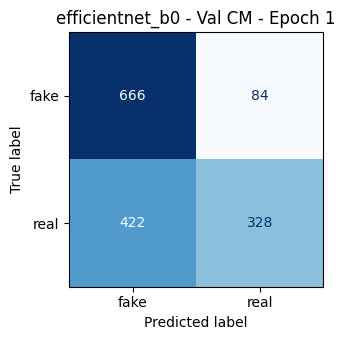

Epoch 2/5: train_loss=0.6020 train_acc=0.687 val_loss=0.5882 val_acc=0.696 time=452.6s
  Val predicted distribution: {'real': 424, 'fake': 1076}
  Val true distribution     : {'real': 750, 'fake': 750}


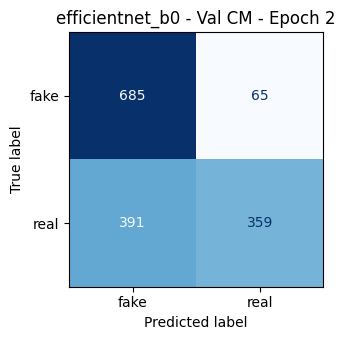

Epoch 3/5: train_loss=0.5670 train_acc=0.723 val_loss=0.5637 val_acc=0.723 time=447.6s
  Val predicted distribution: {'real': 467, 'fake': 1033}
  Val true distribution     : {'real': 750, 'fake': 750}


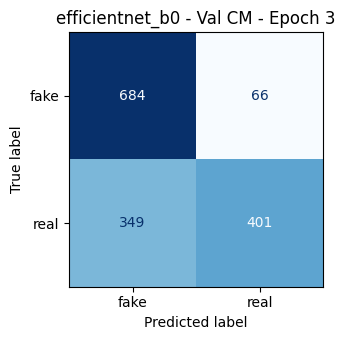

Epoch 4/5: train_loss=0.5496 train_acc=0.729 val_loss=0.5409 val_acc=0.737 time=446.1s
  Val predicted distribution: {'real': 510, 'fake': 990}
  Val true distribution     : {'real': 750, 'fake': 750}


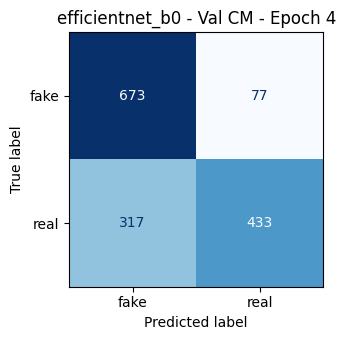

Epoch 5/5: train_loss=0.5384 train_acc=0.733 val_loss=0.5266 val_acc=0.748 time=446.3s
  Val predicted distribution: {'real': 546, 'fake': 954}
  Val true distribution     : {'real': 750, 'fake': 750}


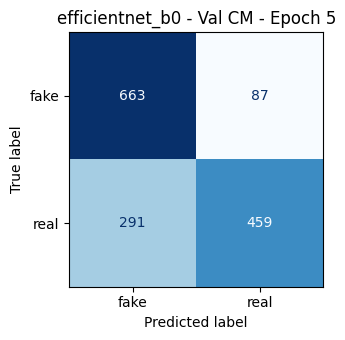


efficientnet_b0: best val_acc=0.748
Avg epoch time : 448.8s
Total time     : 37.4 min

=== PHASE 2: Full fine-tune - efficientnet_b0 ===
Unfrozen — trainable params: 4,010,110
Training efficientnet_b0 [phase2] | epochs=5 lr=1e-05 freeze=False
Trainable params: 4,010,110 / 4,010,110
Epoch 1/5: train_loss=0.5105 train_acc=0.750 val_loss=0.4948 val_acc=0.767 time=451.8s
  Val predicted distribution: {'real': 533, 'fake': 967}
  Val true distribution     : {'real': 750, 'fake': 750}


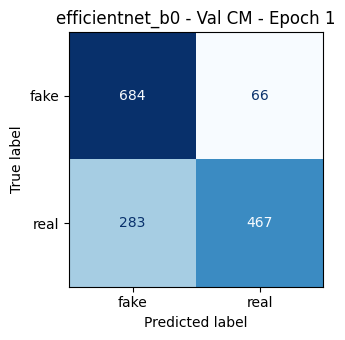

Epoch 2/5: train_loss=0.4814 train_acc=0.775 val_loss=0.4653 val_acc=0.790 time=445.2s
  Val predicted distribution: {'real': 559, 'fake': 941}
  Val true distribution     : {'real': 750, 'fake': 750}


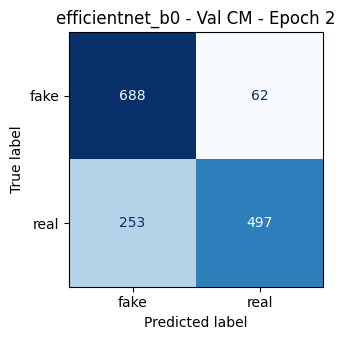

Epoch 3/5: train_loss=0.4442 train_acc=0.796 val_loss=0.4337 val_acc=0.809 time=440.7s
  Val predicted distribution: {'real': 607, 'fake': 893}
  Val true distribution     : {'real': 750, 'fake': 750}


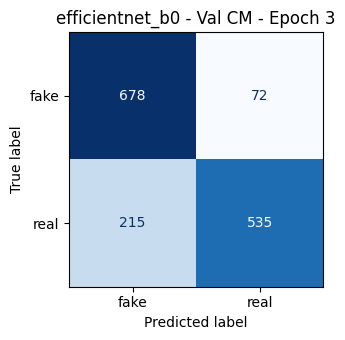

Epoch 4/5: train_loss=0.4165 train_acc=0.812 val_loss=0.4243 val_acc=0.805 time=444.2s
  Val predicted distribution: {'real': 564, 'fake': 936}
  Val true distribution     : {'real': 750, 'fake': 750}


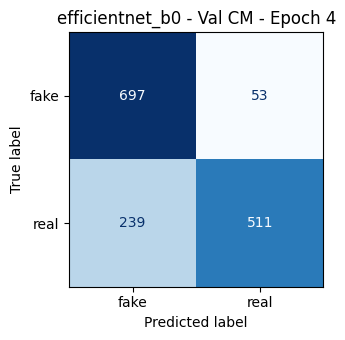

Epoch 5/5: train_loss=0.3962 train_acc=0.825 val_loss=0.3874 val_acc=0.833 time=445.6s
  Val predicted distribution: {'real': 613, 'fake': 887}
  Val true distribution     : {'real': 750, 'fake': 750}


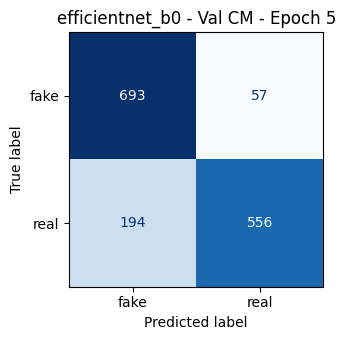


efficientnet_b0: best val_acc=0.833
Avg epoch time : 445.5s
Total time     : 37.1 min

Best val_acc across both phases: 0.833 (from phase2)


In [25]:
# 7. Two-phase training for best accuracy
#
# Phase 1: Freeze backbone, train only the classifier head (5 epochs, LR=1e-4)
#   → Forces the model to learn from pretrained ImageNet features first
#   → Avoids corrupting pretrained weights with random gradients early on
#
# Phase 2: Unfreeze entire backbone, fine-tune end-to-end (5 epochs, LR=1e-5)
#   → Allows backbone to adapt its features to FAKE vs REAL task
#   → Lower LR prevents overwriting the good features learned in Phase 1
#
# This two-phase approach typically gives 5-10% higher accuracy than
# training end-to-end from scratch or with a fully frozen backbone alone.

MODEL_NAMES = ['efficientnet_b0']
results = {}

for name in MODEL_NAMES:
    print(f'\n=== PHASE 1: Frozen backbone - {name} ===')
    r1 = train_model(name, freeze_backbone=True, epochs=5, lr=1e-4, phase_label='phase1')

    print(f'\n=== PHASE 2: Full fine-tune - {name} ===')
    # Unfreeze all layers of the already-trained model
    for param in r1['model'].parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in r1['model'].parameters() if p.requires_grad)
    print(f'Unfrozen — trainable params: {trainable:,}')

    r2 = train_model(name, freeze_backbone=False, epochs=5, lr=1e-5,
                     phase_label='phase2', pretrained_model=r1['model'])

    # Keep the best checkpoint across both phases
    best_acc = max(r1['best_val_acc'], r2['best_val_acc'])
    best_result = r1 if r1['best_val_acc'] >= r2['best_val_acc'] else r2
    print(f'\nBest val_acc across both phases: {best_acc:.3f} '
          f'(from {"phase1" if best_result is r1 else "phase2"})')

    results[name] = best_result


=== PHASE 2 CONTINUED ===
Training efficientnet_b0 [phase2_cont] | epochs=10 lr=1e-05 freeze=False
Trainable params: 4,010,110 / 4,010,110
Epoch 1/10: train_loss=0.3143 train_acc=0.872 val_loss=0.3024 val_acc=0.874 time=452.9s
  Val predicted distribution: {'real': 689, 'fake': 811}
  Val true distribution     : {'real': 750, 'fake': 750}


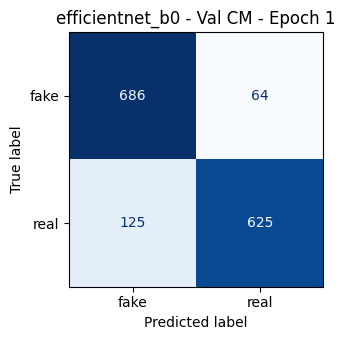

Epoch 2/10: train_loss=0.3081 train_acc=0.872 val_loss=0.2909 val_acc=0.877 time=447.3s
  Val predicted distribution: {'real': 695, 'fake': 805}
  Val true distribution     : {'real': 750, 'fake': 750}


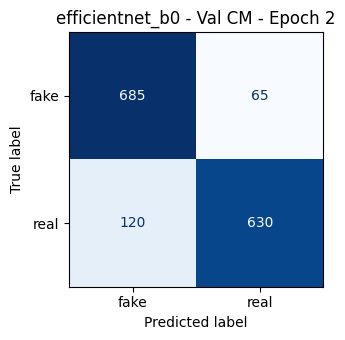

Epoch 3/10: train_loss=0.2983 train_acc=0.873 val_loss=0.2826 val_acc=0.885 time=449.2s
  Val predicted distribution: {'real': 697, 'fake': 803}
  Val true distribution     : {'real': 750, 'fake': 750}


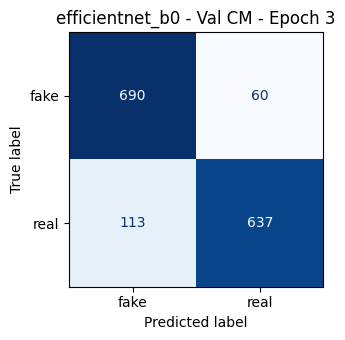

Epoch 4/10: train_loss=0.2852 train_acc=0.880 val_loss=0.2718 val_acc=0.890 time=453.3s
  Val predicted distribution: {'real': 709, 'fake': 791}
  Val true distribution     : {'real': 750, 'fake': 750}


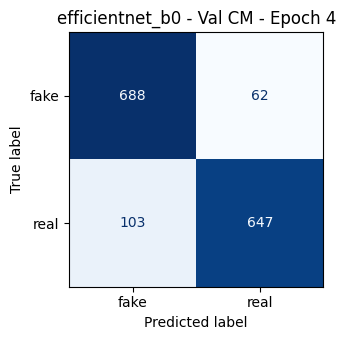

Epoch 5/10: train_loss=0.2679 train_acc=0.890 val_loss=0.2628 val_acc=0.895 time=445.8s
  Val predicted distribution: {'real': 724, 'fake': 776}
  Val true distribution     : {'real': 750, 'fake': 750}


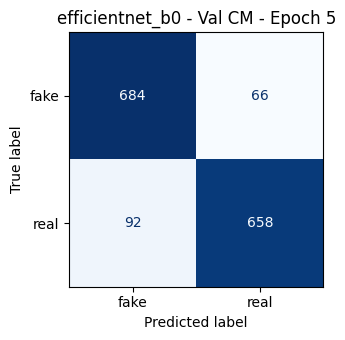

Epoch 6/10: train_loss=0.2761 train_acc=0.887 val_loss=0.2581 val_acc=0.897 time=465.0s
  Val predicted distribution: {'real': 720, 'fake': 780}
  Val true distribution     : {'real': 750, 'fake': 750}


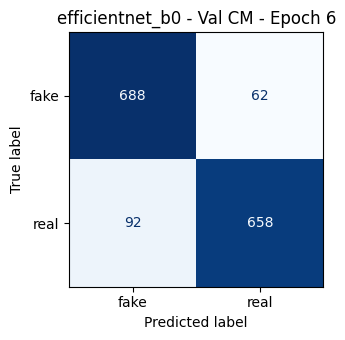

Epoch 7/10: train_loss=0.2624 train_acc=0.895 val_loss=0.2606 val_acc=0.892 time=442.7s
  Val predicted distribution: {'real': 698, 'fake': 802}
  Val true distribution     : {'real': 750, 'fake': 750}


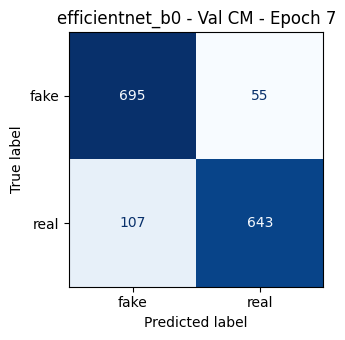

Epoch 8/10: train_loss=0.2664 train_acc=0.887 val_loss=0.2479 val_acc=0.901 time=462.4s
  Val predicted distribution: {'real': 717, 'fake': 783}
  Val true distribution     : {'real': 750, 'fake': 750}


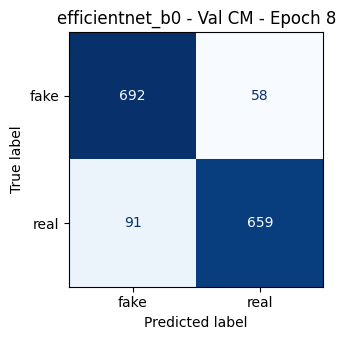

Epoch 9/10: train_loss=0.2523 train_acc=0.896 val_loss=0.2436 val_acc=0.904 time=465.7s
  Val predicted distribution: {'real': 724, 'fake': 776}
  Val true distribution     : {'real': 750, 'fake': 750}


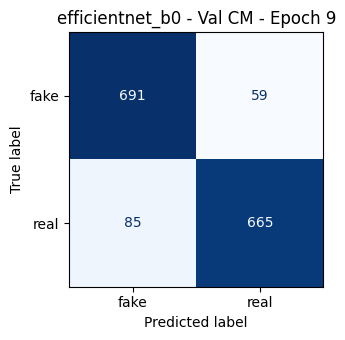

Epoch 10/10: train_loss=0.2346 train_acc=0.903 val_loss=0.2366 val_acc=0.907 time=457.7s
  Val predicted distribution: {'real': 736, 'fake': 764}
  Val true distribution     : {'real': 750, 'fake': 750}


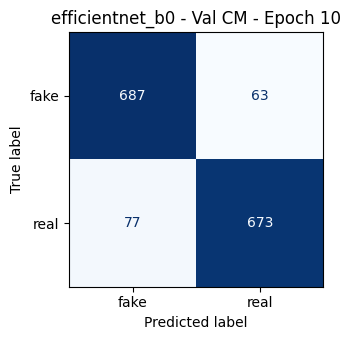


efficientnet_b0: best val_acc=0.907
Avg epoch time : 454.2s
Total time     : 75.7 min


In [27]:
# Continue Phase 2 from where it left off — no restart needed
print('=== PHASE 2 CONTINUED ===')
for param in results['efficientnet_b0']['model'].parameters():
    param.requires_grad = True

r3 = train_model('efficientnet_b0', freeze_backbone=False, epochs=10,
                 lr=1e-5, phase_label='phase2_cont',
                 pretrained_model=results['efficientnet_b0']['model'])
results['efficientnet_b0'] = r3

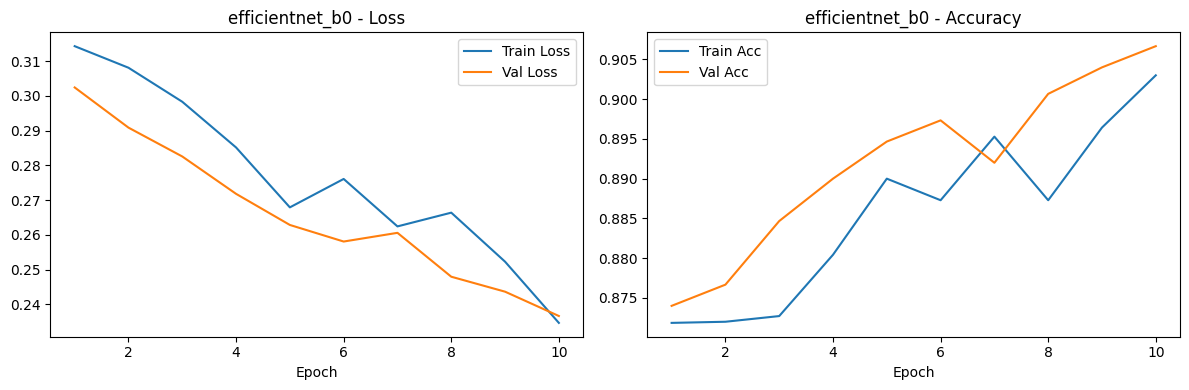

In [28]:
# 8. Plot training curves
fig, axes = plt.subplots(len(MODEL_NAMES), 2, figsize=(12, 4*len(MODEL_NAMES)))
if len(MODEL_NAMES) == 1:
    axes = axes.reshape(1, 2)

for i, name in enumerate(MODEL_NAMES):
    h = results[name]['history']
    epochs = range(1, EPOCHS+1)

    axes[i,0].plot(epochs, h['train_loss'], label='Train Loss')
    axes[i,0].plot(epochs, h['val_loss'], label='Val Loss')
    axes[i,0].set_title(f'{name} - Loss')
    axes[i,0].set_xlabel('Epoch'); axes[i,0].legend()

    axes[i,1].plot(epochs, h['train_acc'], label='Train Acc')
    axes[i,1].plot(epochs, h['val_acc'], label='Val Acc')
    axes[i,1].set_title(f'{name} - Accuracy')
    axes[i,1].set_xlabel('Epoch'); axes[i,1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

In [29]:
# 9. Evaluate on test set + metrics
def evaluate(model):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
                p = model(imgs).argmax(1).cpu().numpy()
            preds.extend(p)
            labels.extend(lbls.numpy())
    return np.array(preds), np.array(labels)

comparison = []
eval_cache = {}
for name in MODEL_NAMES:
    preds, labels = evaluate(results[name]['model'])
    eval_cache[name] = (preds, labels)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, pos_label=0, zero_division=0)
    rec = recall_score(labels, preds, pos_label=0, zero_division=0)
    f1 = f1_score(labels, preds, pos_label=0, zero_division=0)

    comparison.append({
        'Model': name,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1,
        'Train Time (min)': results[name]['time']/60
    })
    print(f'\n--- {name} ---')
    print(classification_report(labels, preds, target_names=CLASS_NAMES))

print('\n=== Results ===')
print(f"{'Model':<18}{'Accuracy':>10}{'Precision':>11}{'Recall':>9}{'F1':>9}{'Time(min)':>11}")
for row in comparison:
    print(f"{row['Model']:<18}{row['Accuracy']:>10.4f}{row['Precision']:>11.4f}{row['Recall']:>9.4f}{row['F1']:>9.4f}{row['Train Time (min)']:>11.1f}")


--- efficientnet_b0 ---
              precision    recall  f1-score   support

        fake       0.89      0.93      0.91       750
        real       0.93      0.88      0.90       750

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500


=== Results ===
Model               Accuracy  Precision   Recall       F1  Time(min)
efficientnet_b0       0.9073     0.8882   0.9320   0.9096       75.7


Best model: efficientnet_b0 (F1=0.9096)


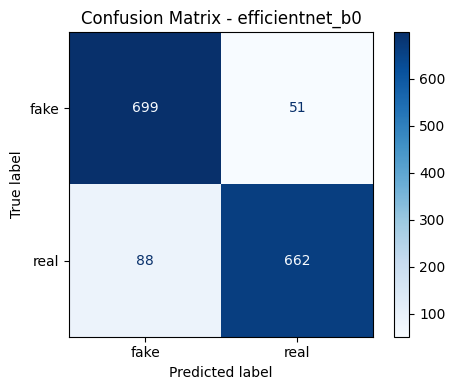

In [30]:
# 10. Best model + confusion matrix
best = max(comparison, key=lambda r: r['F1'])
BEST_NAME = best['Model']
best_model = results[BEST_NAME]['model']
print(f'Best model: {BEST_NAME} (F1={best["F1"]:.4f})')

preds, labels = eval_cache[BEST_NAME]
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix - {BEST_NAME}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

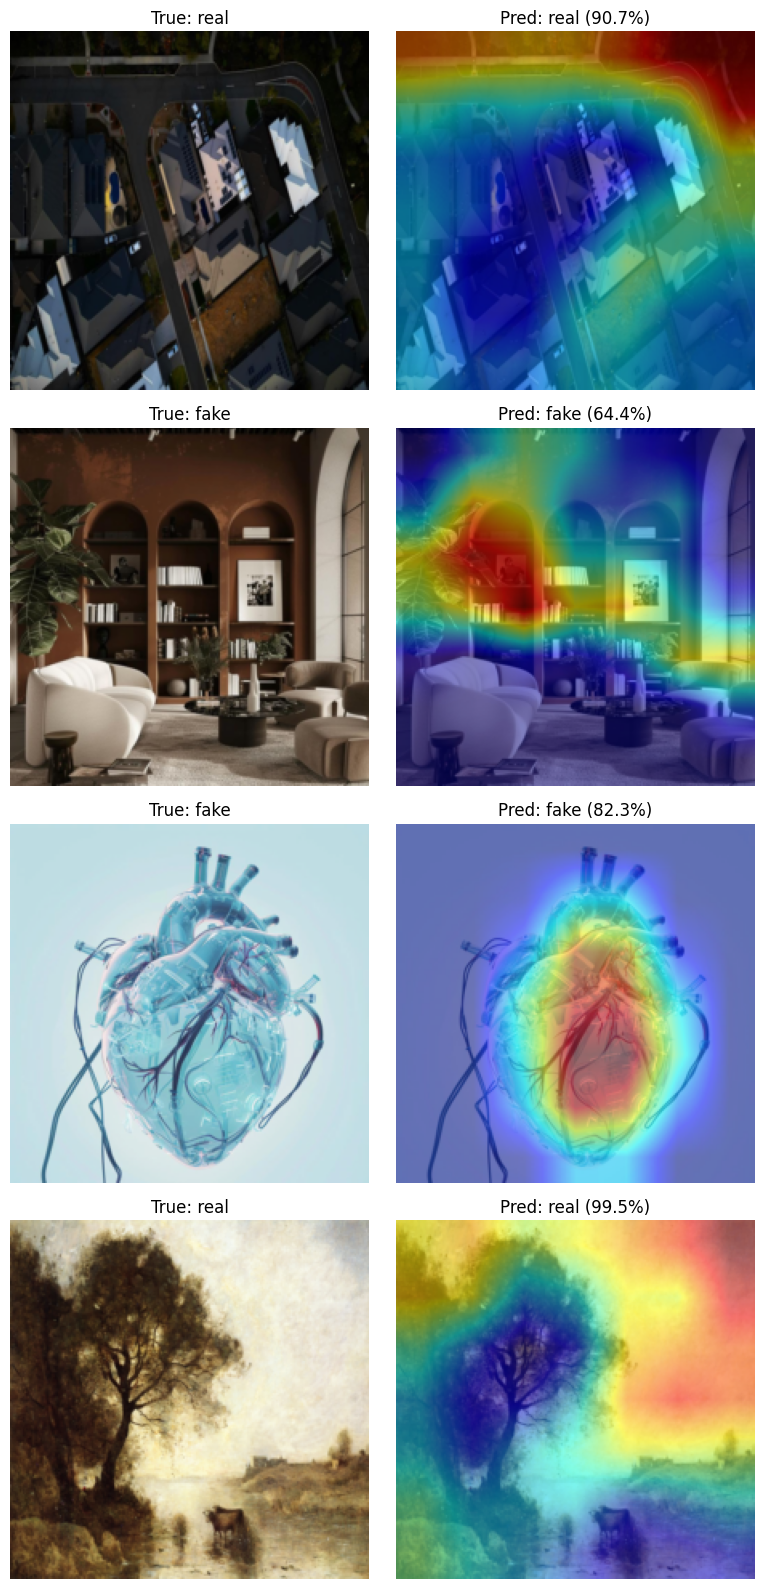

In [31]:
# 11. Grad-CAM on a few test images
cam = GradCAM(model=best_model, target_layers=gradcam_layer(best_model, BEST_NAME))

def show_gradcam(dataset, indices):
    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(8, 4*n))
    if n == 1:
        axes = axes.reshape(1, 2)
    mean = np.array(MEAN); std = np.array(STD)

    for i, idx in enumerate(indices):
        img, true_label = dataset[idx]
        input_t = img.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = best_model(input_t)
            pred = out.argmax(1).item()
            conf = torch.softmax(out, 1)[0, pred].item()

        gray_cam = cam(input_tensor=input_t, targets=[ClassifierOutputTarget(pred)])[0]
        rgb = (img.permute(1,2,0).numpy() * std + mean).clip(0,1)
        overlay = show_cam_on_image(rgb.astype(np.float32), gray_cam, use_rgb=True)

        axes[i,0].imshow(rgb)
        axes[i,0].set_title(f'True: {CLASS_NAMES[true_label]}')
        axes[i,0].axis('off')

        axes[i,1].imshow(overlay)
        axes[i,1].set_title(f'Pred: {CLASS_NAMES[pred]} ({conf:.1%})')
        axes[i,1].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_results.png', dpi=120)
    plt.show()

sample_indices = random.sample(range(len(test_ds)), 4)
show_gradcam(test_ds, sample_indices)

In [32]:
# 12. Production inference function
def predict_image(image_path, show_cam=True):
    """
    Predict if an image is AI-generated or Real.
    Returns dict with predicted_class, confidence, class_probabilities.
    """
    best_model.eval()
    img = Image.open(image_path).convert('RGB')
    tensor = eval_tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = best_model(tensor)
        probs = torch.softmax(out, 1)[0].cpu()

    pred_idx = probs.argmax().item()
    pred_class = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx].item()
    class_probs = {c: round(probs[i].item(), 4) for i, c in enumerate(CLASS_NAMES)}

    print(f'Predicted Class : {pred_class}')
    print(f'Confidence      : {confidence:.2%}')
    print(f'Probabilities   : {class_probs}')

    if show_cam:
        gray_cam = cam(input_tensor=tensor, targets=[ClassifierOutputTarget(pred_idx)])[0]
        rgb = (tensor[0].permute(1,2,0).cpu().numpy() * np.array(STD) + np.array(MEAN)).clip(0,1)
        overlay = show_cam_on_image(rgb.astype(np.float32), gray_cam, use_rgb=True)
        fig, axes = plt.subplots(1,2, figsize=(8,4))
        axes[0].imshow(rgb); axes[0].set_title('Original'); axes[0].axis('off')
        axes[1].imshow(overlay); axes[1].set_title(f'{pred_class} ({confidence:.1%})'); axes[1].axis('off')
        plt.tight_layout(); plt.show()

    return {'predicted_class': pred_class, 'confidence': confidence, 'class_probabilities': class_probs}

print('predict_image() ready')

predict_image() ready


Ground truth: fake
Predicted Class : fake
Confidence      : 94.93%
Probabilities   : {'fake': 0.9493, 'real': 0.0507}


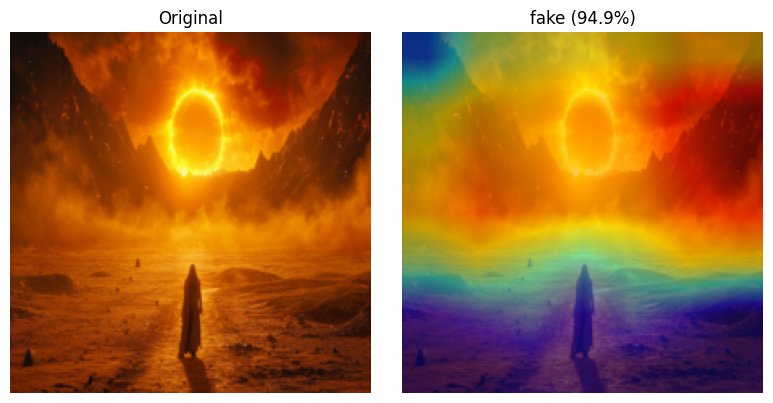

In [33]:
# 13. Test inference on a random test image
idx = random.choice(test_idx)
img_path = all_paths[idx]
true_label = all_labels[idx]
print(f'Ground truth: {CLASS_NAMES[true_label]}')
result = predict_image(img_path, show_cam=True)

In [34]:
# 14. Save best model with metadata + final summary
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_name': BEST_NAME,
    'class_names': CLASS_NAMES,
    'validation_accuracy': best['Accuracy'],
}, 'ai_detector_best.pth')

print('=== FINAL SUMMARY ===')
print(f'Best Model : {BEST_NAME}')
print(f'Reason     : Highest F1 score (best balance of precision and recall)')
print(f'Accuracy   : {best["Accuracy"]:.4f}')
print(f'Precision  : {best["Precision"]:.4f}')
print(f'Recall     : {best["Recall"]:.4f}')
print(f'F1 Score   : {best["F1"]:.4f}')
print(f'Total train time: {results[BEST_NAME]["time"]/60:.1f} min')
print(f'Saved to   : ai_detector_best.pth')

=== FINAL SUMMARY ===
Best Model : efficientnet_b0
Reason     : Highest F1 score (best balance of precision and recall)
Accuracy   : 0.9073
Precision  : 0.8882
Recall     : 0.9320
F1 Score   : 0.9096
Total train time: 75.7 min
Saved to   : ai_detector_best.pth
